# Offset + Demod Evaluation vs SNR — Comparison Plots

Plots for the `results3/` CSVs written by `main3.py` (route `/upload_offset`).

The columns here are **not** the same as `results2/` (which only had `SNR,DetRate`).
Each row is one SNR bin:

| column | meaning |
|---|---|
| `N` | packets sent in this SNR bin |
| `PreambleMissed` | CALoRa never found the preamble (stage 1 failure) |
| `OffsetFail` | `detect_cfo_sto` returned no estimate (stage 2 failure) |
| `CFO_MAE_Hz`, `STO_MAE_samples` | mean absolute error, over packets that produced an estimate |
| `CFO_SuccessRate`, `STO_SuccessRate`, `SymbolAccuracy` | **conditioned** — denominator is only the packets that reached that stage |
| `*_PerPacket` | **unconditioned** — denominator is every packet sent, so a preamble miss counts as wrong |

Success means `|CFO error|` within half a frequency bin (488 Hz at SF7/BW125k) and
`|STO error|` within one chip (8 samples at fs=1 MHz).

Pick the denominator with `METRIC_SCOPE` in the next cell. The two can differ a lot:
if `PreambleMissed` is high, the conditioned numbers look excellent while the
end-to-end ones do not. The summary table below shows which situation you are in.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import os
import glob

results_dir = os.path.join('.', 'results3')

# List all available CSV files
all_csvs = sorted(glob.glob(os.path.join(results_dir, '*.csv')))
print(f'Available result files in {results_dir}:')
for i, f in enumerate(all_csvs):
    print(f'  [{i}] {os.path.basename(f)}')

Available result files in .\results3:
  [0] offset_demod_results_20260819_145216.csv
  [1] offset_demod_results_20260819_145429.csv
  [2] offset_demod_results_20260819_145929.csv
  [3] offset_demod_results_20260819_145951.csv
  [4] offset_demod_results_20260819_150107.csv
  [5] offset_demod_results_20260819_150135.csv
  [6] offset_demod_results_20260819_151036.csv
  [7] offset_demod_results_20260819_151154.csv
  [8] offset_demod_results_20260819_151437.csv
  [9] offset_demod_results_20260819_152359.csv
  [10] offset_demod_results_20260819_152529.csv
  [11] offset_demod_results_20260819_152534.csv
  [12] offset_demod_results_20260819_152549.csv
  [13] offset_demod_results_20260819_152553.csv
  [14] offset_demod_results_20260819_152620.csv
  [15] offset_demod_results_20260819_152625.csv
  [16] offset_demod_results_20260819_152626.csv
  [17] offset_demod_results_20260819_152926.csv
  [18] offset_demod_results_20260819_152932.csv
  [19] offset_demod_results_20260819_153021.csv
  [20] offse

In [2]:
# ╔═══════════════════════════════════════════════════════════╗
# ║  EDIT HERE: the files you want to compare (4 slots, add or remove freely)  ║
# ║  Use the exact filenames (without path) from the list above                ║
# ╚═══════════════════════════════════════════════════════════╝

selected_files = [
    'offset_demod_results_20260820_clean.csv',
    'offset_demod_results_20260820_cfo.csv',
    'offset_demod_results_20260820_sto.csv',
    'offset_demod_results_20260820_cfosto.csv',
]

# Friendly legend labels, one per file. Leave a slot as '' to fall back to the timestamp.
labels = [
    'Clean',
    'CFO',
    'STO',
    'CFO and STO',
]

# ── Which denominator to plot ─────────────────────────────────────
#   'conditioned' -> CFO_SuccessRate / STO_SuccessRate / SymbolAccuracy
#                    only packets that reached the stage. "When it ran, how good was it?"
#   'per_packet'  -> the *_PerPacket columns
#                    every packet sent, so a CALoRa preamble miss counts as wrong.
#                    This is the true end-to-end number.
METRIC_SCOPE = 'conditioned'

for fname in selected_files:
    path = os.path.join(results_dir, fname)
    print(('✅ ' if os.path.isfile(path) else '⚠️  NOT FOUND: ') + fname)

✅ offset_demod_results_20260820_clean.csv
✅ offset_demod_results_20260820_cfo.csv
✅ offset_demod_results_20260820_sto.csv
✅ offset_demod_results_20260820_cfosto.csv


In [3]:
# ── Context: how many packets actually reached the estimator? ─────────────
# Read this before trusting the 'conditioned' curves. A run with a high
# PreambleMissed% can show 100% conditioned accuracy on a handful of packets.

rows = []
for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        continue
    df = pd.read_csv(path)
    n = df['N'].sum()
    pre = df['PreambleMissed'].sum()
    off = df['OffsetFail'].sum()
    rows.append({
        'label': labels[i] if i < len(labels) and labels[i] else fname,
        'file': fname,
        'N': n,
        'PreMiss': pre,
        'PreMiss%': round(100 * pre / n, 1) if n else 0.0,
        'OffFail': off,
        'OffFail%': round(100 * off / n, 1) if n else 0.0,
        'reached': n - pre - off,
        'SNR range': f"{df['SNR'].min()} .. {df['SNR'].max()}",
    })

pd.DataFrame(rows).set_index('label')

,file,N,PreMiss,PreMiss%,OffFail,OffFail%,reached,SNR range
label,,,,,,,,
Clean,offset_demod_results_20260820_clean.csv,2000,0,0.0,54,2.7,1946,-24 .. -5
CFO,offset_demod_results_20260820_cfo.csv,2000,4,0.2,146,7.3,1850,-24 .. -5
STO,offset_demod_results_20260820_sto.csv,2000,1190,59.5,108,5.4,702,-24 .. -5
CFO and STO,offset_demod_results_20260820_cfosto.csv,2000,993,49.6,139,7.0,868,-24 .. -5


In [4]:
# ── Shared plotting helper ───────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

# Same slot order as plot_results2.ipynb so a given run keeps its colour across
# notebooks. Red is reserved for the threshold line.
PALETTE = ['black', 'green', 'blue', '#4a3aa7', '#e87ba4', '#008300', '#eda100']
THRESHOLD_COLOR = '#e34948'
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

COLUMNS = {
    'conditioned': {'cfo': 'CFO_SuccessRate',
                    'sto': 'STO_SuccessRate',
                    'sym': 'SymbolAccuracy'},
    'per_packet':  {'cfo': 'CFO_SuccessRatePerPacket',
                    'sto': 'STO_SuccessRatePerPacket',
                    'sym': 'SymbolAccuracyPerPacket'},
}


def plot_metric(key, ylabel, title, outfile, threshold=0.9):
    column = COLUMNS[METRIC_SCOPE][key]
    fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

    for i, fname in enumerate(selected_files):
        path = os.path.join(results_dir, fname)
        if not os.path.isfile(path):
            continue

        df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
        # main3.py writes these columns as percentages (0-100); PercentFormatter
        # below expects a 0-1 fraction, so the scale is fixed rather than guessed.
        y = df[column] / 100.0

        lbl = labels[i] if i < len(labels) and labels[i] else \
            fname.replace('offset_demod_results_', '').replace('.csv', '')
        color = PALETTE[i % len(PALETTE)]

        ax.plot(
            df['SNR'], y,
            marker=MARKERS[i % len(MARKERS)],
            markersize=7, linewidth=2.2,
            color=color,
            markerfacecolor='white', markeredgewidth=2,
            markeredgecolor=color,
            label=lbl
        )

    if threshold is not None:
        ax.axhline(y=threshold, color=THRESHOLD_COLOR, linestyle='--', linewidth=2,
                   zorder=1, label=f'{threshold:.0%} Threshold')

    scope_note = ('denominator: every packet sent' if METRIC_SCOPE == 'per_packet'
                  else 'denominator: packets that reached this stage')
    ax.set_xlabel('SNR (dB)', fontsize=15, fontweight='bold', labelpad=8)
    ax.set_ylabel(ylabel, fontsize=15, fontweight='bold', labelpad=8)
    ax.set_title(f'{title}\n({scope_note})', fontsize=16, fontweight='bold', pad=14)
    ax.set_ylim(-0.1, 1.10)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11.5, loc='lower right', frameon=True, framealpha=0.9,
              edgecolor='#c3c2b7')
    ax.grid(True, axis='y', alpha=0.4)
    ax.grid(False, axis='x')

    plt.tight_layout()
    out = os.path.join(results_dir, outfile)
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'\nPlot saved to {out}')

## 1. SNR vs CFO success rate

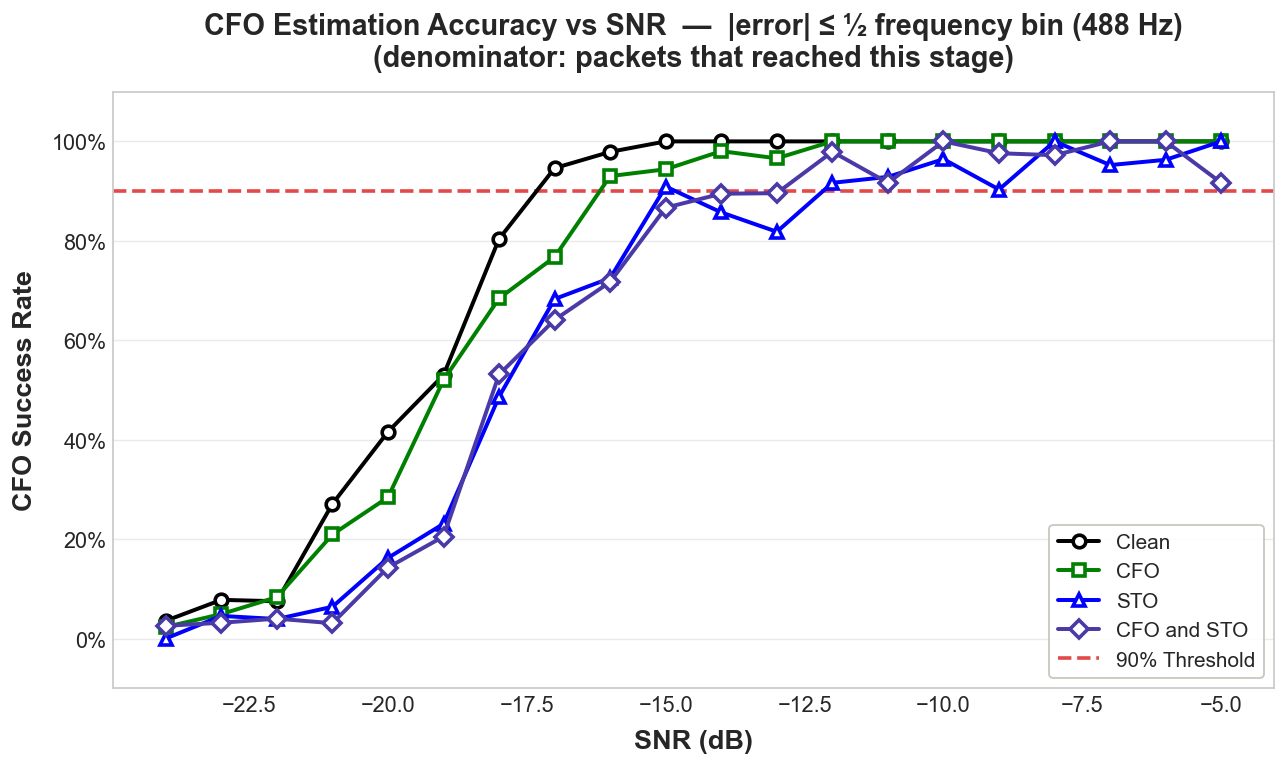


Plot saved to .\results3\cfo_success_conditioned.png


In [5]:
plot_metric(
    'cfo',
    ylabel='CFO Success Rate',
    title='CFO Estimation Accuracy vs SNR  —  |error| ≤ ½ frequency bin (488 Hz)',
    outfile=f'cfo_success_{METRIC_SCOPE}.png',
)

## 2. SNR vs STO success rate

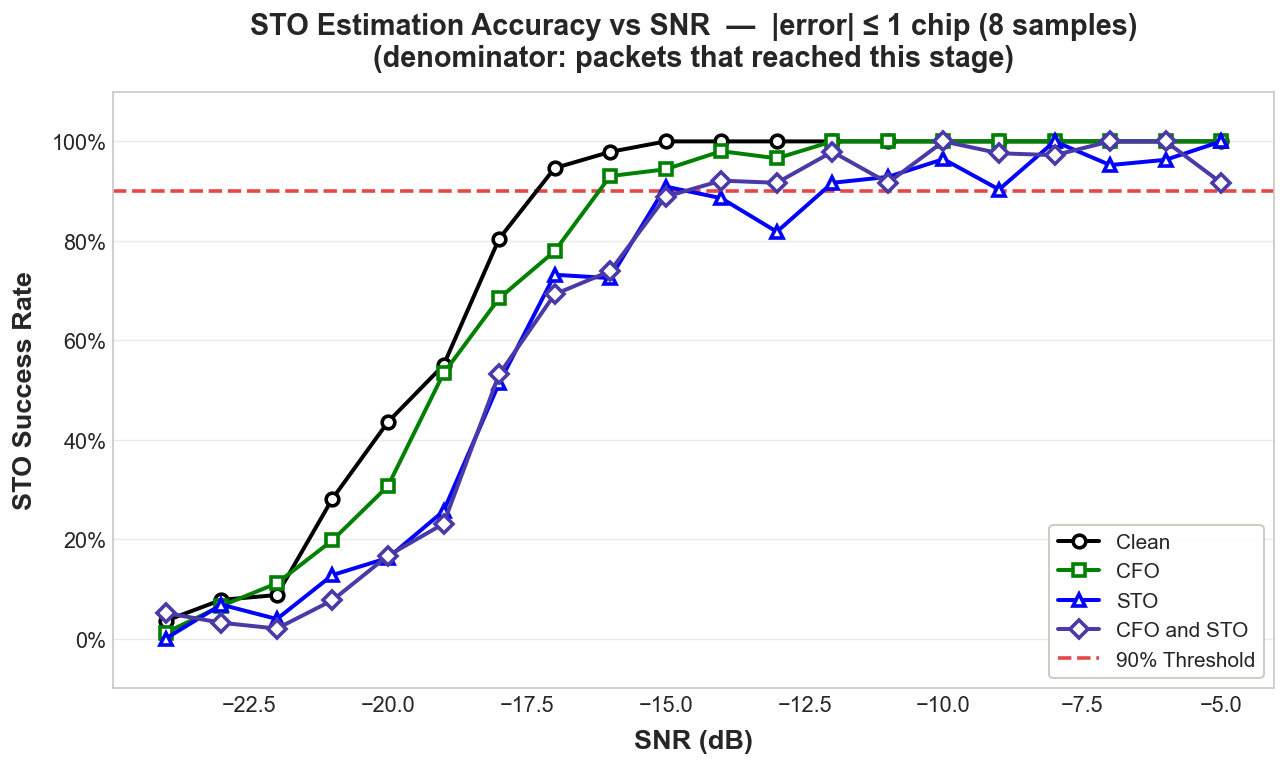


Plot saved to .\results3\sto_success_conditioned.png


In [6]:
plot_metric(
    'sto',
    ylabel='STO Success Rate',
    title='STO Estimation Accuracy vs SNR  —  |error| ≤ 1 chip (8 samples)',
    outfile=f'sto_success_{METRIC_SCOPE}.png',
)

## 3. SNR vs symbol demodulation accuracy

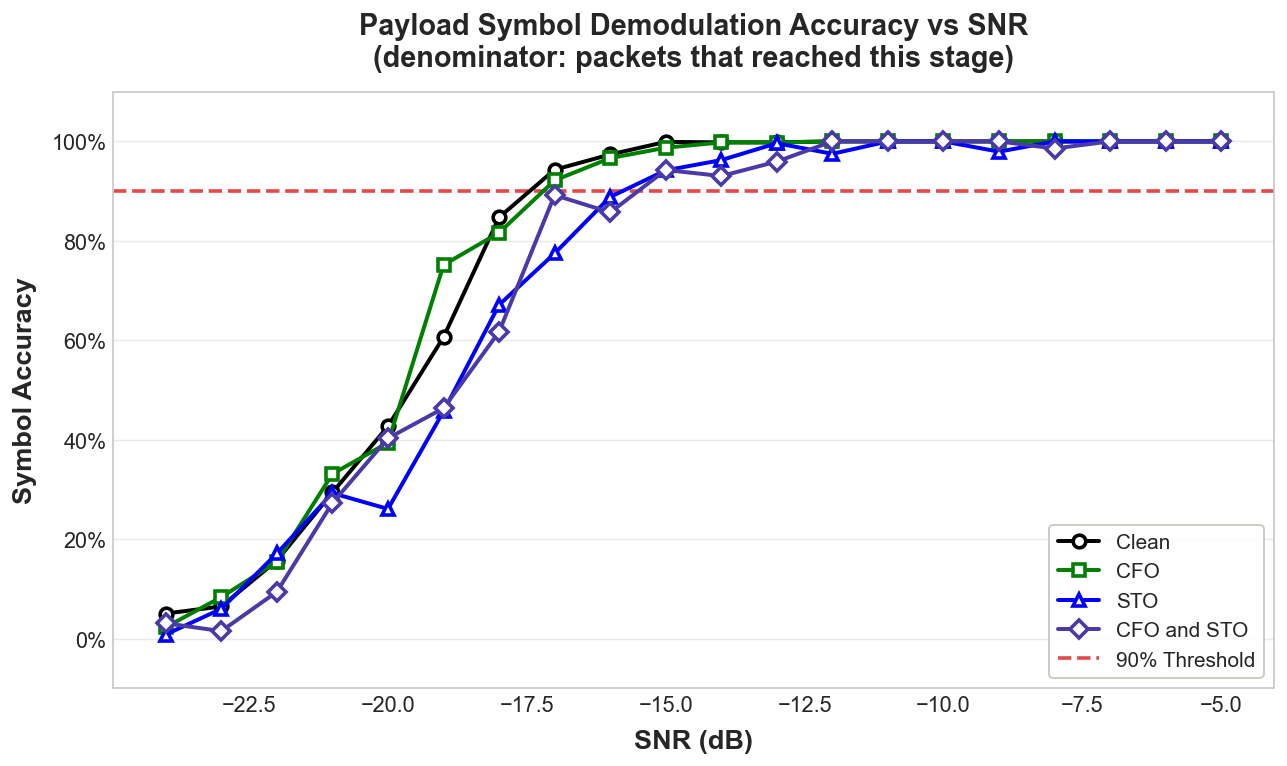


Plot saved to .\results3\symbol_accuracy_conditioned.png


In [7]:
plot_metric(
    'sym',
    ylabel='Symbol Accuracy',
    title='Payload Symbol Demodulation Accuracy vs SNR',
    outfile=f'symbol_accuracy_{METRIC_SCOPE}.png',
)